# COMP5318 Assignment 1: Rice Classification

##### Group number: 74
##### Student 1 SID: 550175951

---
## 📋 Notebook Overview

This notebook implements **Part 2** of the COMP5318 Assignment 1 — Rice Grain Classification.

| Section | Description |
|---|---|
| **1. Data Pre-processing** | Load dataset, handle missing values, normalise features |
| **2. Build Classifiers** | Train and tune Gradient Boosting and SVM models |
| **3. Results & Evaluation** | Accuracy, F1 scores, confusion matrices, ROC curves |
| **4. Reflection** | Analysis and comparison of model performance |

**Dataset:** `rice-final2.csv` — binary classification task (class1 vs class2)  
**Models:** Gradient Boosting Classifier · Support Vector Machine (SVM)  
**Evaluation:** 10-fold Stratified Cross-Validation with GridSearchCV hyperparameter tuning


---
## 1. Data Pre-processing

Before training any model, the raw data must be cleaned and transformed.  
This section covers:
- **Importing** required libraries
- **Loading** the rice dataset
- **Handling missing values** using mean imputation
- **Normalising** features to the [0, 1] range
- **Encoding** class labels as binary integers (0 / 1)


### 📦 Step 1 — Import Libraries

We import all required libraries up front:
- `numpy` / `pandas` — data handling
- `SimpleImputer` — fills missing values with the column mean
- `MinMaxScaler` — normalises features to [0, 1]
- `StratifiedKFold` — ensures each fold preserves the class ratio during cross-validation


In [5]:
# Core data handling
import numpy as np                          # numerical operations
import pandas as pd                         # dataframe operations

# Preprocessing utilities
from sklearn.impute import SimpleImputer    # replace NaN with column mean
from sklearn.preprocessing import MinMaxScaler  # scale features to [0,1]

# Cross-validation
from sklearn.model_selection import StratifiedKFold  # preserves class balance per fold


### 🔇 Step 2 — Suppress Future Warnings
Hides deprecation warnings from sklearn to keep output clean.

In [6]:
# Suppress FutureWarning messages from sklearn during cross-validation
# This keeps the output clean without affecting results
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)


### 📂 Step 3 — Load the Dataset

- `na_values="?"` — treats `?` characters in the CSV as missing values (NaN)
- `.isnull().sum()` — counts missing values per column
- `.shape` — confirms the number of rows and features
- `.head()` — previews the first 5 rows


In [7]:
# import os
# os.chdir(r'c:\Users\HP\OneDrive - The University of Sydney (Students)\Desktop\semester 3\COMP4318 & COMP5318\Assignment 1')
# Load the rice dataset: rice-final2.csv
df = pd.read_csv("rice-final2.csv", na_values="?")
df.isnull().sum()
df.shape
df.head()

,Area,Perimiter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,class
0,12573.0,461.466003,192.903351,84.572075,0.898772,12893.0,0.550433,class2
1,12845.0,464.121002,194.332214,85.524338,0.897952,13125.0,0.774962,class2
2,14055.0,488.748993,207.751755,87.250328,0.907536,14484.0,0.550076,class1
3,14412.0,490.324005,207.476135,89.689514,0.901735,14703.0,0.598853,class1
4,14658.0,477.117004,189.566635,99.997780,0.849551,15048.0,0.649504,class2


### ⚙️ Step 4 — Pre-process the Dataset

Four key steps are applied here:

| Step | Method | Reason |
|---|---|---|
| Separate features/labels | `iloc[:,:-1]` / `iloc[:,-1]` | Split X (features) and y (target) |
| Impute missing values | `SimpleImputer(strategy="mean")` | Replace NaN with column mean — avoids data loss |
| Normalise features | `MinMaxScaler()` | Scales all features to [0,1] — important for distance-based models like SVM |
| Encode labels | `np.where(y=="class1", 0, 1)` | Converts string labels to binary integers for sklearn |

> ⚠️ **Important:** `fit_transform()` is used on training data. On test data we use only `transform()` to avoid data leakage.


In [8]:
# ── Separate features and target label ──────────────────────────────────────
X = df.iloc[:,:-1]   # all columns except the last → feature matrix
y = df.iloc[:,-1]    # last column only → target labels

# ── Handle missing values ────────────────────────────────────────────────────
# Replace any NaN values with the mean of that column
# fit_transform() learns the mean from X then applies it
imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
X = imputer.fit_transform(X)

# ── Normalise features to [0, 1] ──────────────────────────────────────────────
# MinMaxScaler ensures no single feature dominates due to scale differences
# Critical for SVM which is sensitive to feature magnitudes
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# ── Encode class labels as binary integers ────────────────────────────────────
# class1 → 0,  class2 → 1
y = np.where(y=="class1", 0, 1)

# Confirm final shapes
print("Feature matrix shape:", X.shape)  # (n_samples, n_features)
print("Label vector shape: ", y.shape)   # (n_samples,)


Feature matrix shape: (1400, 7)
Label vector shape:  (1400,)


### 🖨️ Step 5 — Print Pre-processed Data

The `print_data()` helper function prints the first `n_rows` rows of the pre-processed dataset, 
formatted to 4 decimal places as required by the assignment specification.


In [9]:
# Print first ten rows of pre-processed dataset to 4 decimal places as per assignment spec
# A function is provided to assist

def print_data(X, y, n_rows=10):
    """Takes a numpy data array and target and prints the first ten rows.
    
    Arguments:
        X: numpy array of shape (n_examples, n_features)
        y: numpy array of shape (n_examples)
        n_rows: numpy of rows to print
    """
    for example_num in range(n_rows):
        for feature in X[example_num]:
            print("{:.4f}".format(feature), end=",")

        if example_num == len(X)-1:
            print(y[example_num],end="")
        else:
            print(y[example_num])
            


Print the first 10 rows of the pre-processed dataset:

In [10]:
print_data(X,y)

0.4628,0.5406,0.5113,0.4803,0.7380,0.4699,0.1196,1
0.4900,0.5547,0.5266,0.5018,0.7319,0.4926,0.8030,1
0.6109,0.6847,0.6707,0.5409,0.8032,0.6253,0.1185,0
0.6466,0.6930,0.6677,0.5961,0.7601,0.6467,0.2669,0
0.6712,0.6233,0.4755,0.8293,0.3721,0.6803,0.4211,1
0.2634,0.2932,0.2414,0.4127,0.5521,0.2752,0.2825,1
0.8175,0.9501,0.9515,0.5925,0.9245,0.8162,0.0000,0
0.3174,0.3588,0.3601,0.3908,0.6921,0.3261,0.8510,1
0.3130,0.3050,0.2150,0.5189,0.3974,0.3159,0.4570,1
0.5120,0.5237,0.4409,0.6235,0.5460,0.5111,0.3155,1


---
## 2. Build Classifiers

This section builds and evaluates all classifiers in two parts:

- **Part 1** — Logistic Regression & Naïve Bayes, evaluated with 10-fold cross-validation (no tuning)
- **Part 2** — Gradient Boosting & SVM, evaluated with GridSearchCV hyperparameter tuning

All models use the same **10-fold Stratified Cross-Validation** to ensure fair and comparable results.


### Part 1 — Cross-Validation Without Parameter Tuning

Logistic Regression and Naïve Bayes are evaluated using `cross_val_score` with the shared  
`StratifiedKFold` object. No hyperparameter search is performed — default parameters are used.


#### 🔀 Stratified K-Fold Cross-Validation Setup

`StratifiedKFold` splits the data into 10 folds while preserving the class ratio in each fold.  
This is important for imbalanced datasets — it ensures every fold has a representative mix of both classes.

- `n_splits=10` — 10 folds (standard for this assignment)
- `shuffle=True` — randomly shuffles data before splitting
- `random_state=0` — ensures reproducibility across runs


In [12]:
# Create the 10-fold stratified cross-validator
# This single object is reused by ALL classifiers to ensure identical splits
cvKFold = StratifiedKFold(
    n_splits=10,      # divide data into 10 equal folds
    shuffle=True,     # shuffle before splitting for better randomness
    random_state=0    # fixed seed for reproducibility
)


Confirm the unique class labels in the encoded target vector:

In [ ]:
print(set(y))

{np.int64(0), np.int64(1)}


#### 📈 Logistic Regression

Logistic Regression fits a linear decision boundary between the two rice classes.  
- `max_iter=1000` — increased from default 100 to allow full convergence on this dataset  
- `random_state=0` — reproducible results  
- Evaluated using `cross_val_score` with accuracy as the metric


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Initialise Logistic Regression
# max_iter=1000 prevents convergence warnings on this dataset
lr_model = LogisticRegression(random_state=0, max_iter=1000)

# Evaluate using 10-fold stratified cross-validation
# cross_val_score returns one accuracy score per fold
lr_scores = cross_val_score(lr_model, X, y, cv=cvKFold, scoring='accuracy')
lr_mean = lr_scores.mean()  # average accuracy across all 10 folds

print('Per-fold scores:', lr_scores)
print('LogR average cross-validation accuracy: {:.4f}'.format(lr_mean))


[0.91428571 0.93571429 0.96428571 0.94285714 0.95       0.92857143
 0.94285714 0.95       0.89285714 0.96428571]
LogR average cross-validation accuracy: 0.9386


#### 📊 Naïve Bayes (Gaussian)

`GaussianNB` assumes each feature follows a Gaussian (normal) distribution within each class,  
and that all features are conditionally independent given the class label.  
While fast and simple, this independence assumption may hurt accuracy when features are correlated  
(e.g. rice grain area and perimeter are likely correlated).


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score

# Gaussian Naïve Bayes — assumes features are normally distributed per class
# No hyperparameters to tune; uses default settings
nb_model = GaussianNB()

# Evaluate with the same 10-fold CV used for Logistic Regression
nb_scores = cross_val_score(nb_model, X, y, cv=cvKFold, scoring='accuracy')
nb_mean = nb_scores.mean()  # average accuracy across folds

print('Per-fold scores:', nb_scores)
print('NB average cross-validation accuracy: {:.4f}'.format(nb_mean))


[0.9        0.92857143 0.95714286 0.91428571 0.94285714 0.93571429
 0.94285714 0.94285714 0.86428571 0.93571429]
NB average cross-validation accuracy: 0.9264


### Part 1 — Results Summary

Final accuracy scores for Logistic Regression and Naïve Bayes, printed to 4 decimal places.


In [ ]:
# Print results for each classifier in part 1 to 4 decimal places here:
print("LogR average cross-validation accuracy: {:.4f}".format(lr_mean))
print("NB average cross-validation accuracy: {:.4f}".format(nb_mean))

LogR average cross-validation accuracy: 0.9386
NB average cross-validation accuracy: 0.9264


---
### Part 2 — Cross-Validation WITH Hyperparameter Tuning

**Gradient Boosting** and **SVM** are tuned using `GridSearchCV`, which exhaustively  
searches all combinations of the specified hyperparameter grid.

#### Strategy
1. Split data into **80% training** and **20% validation** sets (stratified, `random_state=0`)
2. Run `GridSearchCV` with 10-fold CV on the training set to find the best hyperparameters
3. Evaluate the best model on the held-out validation set
4. Report accuracy, macro F1, and weighted F1

> **Why train/validation split + GridSearchCV?**  
> GridSearchCV finds the best params using CV on training data.  
> The validation set is then a completely unseen set — giving an unbiased estimate of real-world performance.


#### 🌲 Gradient Boosting Classifier

Gradient Boosting builds an ensemble of shallow decision trees sequentially.  
Each new tree corrects the errors of the previous ones, making it powerful for tabular data.

**Hyperparameters being tuned:**

| Parameter | Values Tried | What it controls |
|---|---|---|
| `n_estimators` | 50, 100, 150 | Number of trees in the ensemble |
| `learning_rate` | 0.1, 0.2, 0.3, 0.5 | How much each tree contributes — smaller = more conservative |
| `max_depth` | 1, 3, 5, 7 | Maximum depth of each individual tree — controls complexity |

Total combinations: 3 × 4 × 4 = **48 parameter combinations**, each evaluated with 10-fold CV.


In [14]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, f1_score

# ── Train / Validation split ──────────────────────────────────────────────────
# 80% training data for GridSearchCV, 20% held-out validation for final evaluation
# stratify=y ensures both splits have the same class distribution
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,       # 20% of data reserved for validation
    stratify=y,          # preserve class ratio in both splits
    random_state=0       # reproducibility
)

# ── Gradient Boosting Hyperparameter Grid ─────────────────────────────────────
# GridSearchCV will try every combination of these values
gb_params = {
    'n_estimators':  [50, 100, 150],         # number of boosting rounds (trees)
    'learning_rate': [0.1, 0.2, 0.3, 0.5],  # step size shrinkage
    'max_depth':     [1, 3, 5, 7],           # depth of each tree (1=stump)
}

# ── Grid Search with 10-fold Stratified CV ────────────────────────────────────
# n_jobs=-1 uses all CPU cores in parallel to speed up the search
gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=0),
    gb_params,
    cv=cvKFold,           # the same 10-fold CV used throughout
    scoring='accuracy',   # optimise for accuracy
    n_jobs=-1,            # parallelise across all CPU cores
)

# Fit GridSearchCV on training data — finds the best hyperparameter combination
gb_search.fit(X_train, y_train)

# Extract the best model (already refitted on full X_train with best params)
best_gb = gb_search.best_estimator_
print('Best GB params found:', gb_search.best_params_)

# Best mean CV accuracy across 10 folds (on training data)
print('Gradient Boost CV accuracy: {:.4f}'.format(gb_search.best_score_))

# Generate predictions on the held-out validation set
y_val_gb = best_gb.predict(X_val)

# Validation set metrics — unbiased estimate of real-world performance
print('Gradient Boost validation accuracy:  {:.4f}'.format(accuracy_score(y_val, y_val_gb)))
print('Gradient Boost validation macro F1:  {:.4f}'.format(f1_score(y_val, y_val_gb, average='macro')))
print('Gradient Boost validation weighted F1:{:.4f}'.format(f1_score(y_val, y_val_gb, average='weighted')))




Best GB params found: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 50}
Gradient Boost CV accuracy: 0.9446
Gradient Boost validation accuracy:  0.9429
Gradient Boost validation macro F1:  0.9414
Gradient Boost validation weighted F1:0.9427


#### 🔵 Support Vector Machine (SVM)

SVM finds the maximum-margin hyperplane that best separates the two classes.  
The **RBF (Radial Basis Function) kernel** maps features into a higher-dimensional space,  
allowing SVM to capture non-linear decision boundaries.

**Hyperparameters being tuned:**

| Parameter | Values Tried | What it controls |
|---|---|---|
| `C` | 0.01, 0.1, 1, 5 | Regularisation — low C = wider margin (more misclassifications allowed); high C = strict boundary |
| `gamma` | 0.01, 0.1, 1, 10 | RBF kernel width — low gamma = broad influence; high gamma = tight fit to training points |
| `kernel` | rbf | Kernel function — RBF handles non-linear boundaries |

Total combinations: 4 × 4 × 1 = **16 combinations** × 10 folds = 160 model fits.

> ⚠️ SVM is sensitive to feature scale — this is why MinMaxScaler was applied during pre-processing.


In [15]:
# ── SVM Hyperparameter Grid ──────────────────────────────────────────────────
svc_params = {
    'C':      [0.01, 0.1, 1, 5],     # regularisation strength
    'gamma':  [0.01, 0.1, 1, 10],    # RBF kernel coefficient
    'kernel': ['rbf'],               # radial basis function kernel
}

# ── Grid Search with 10-fold Stratified CV ────────────────────────────────────
svc_search = GridSearchCV(
    SVC(random_state=0),
    svc_params,
    cv=cvKFold,           # same CV splits as all other models
    scoring='accuracy',   # optimise for accuracy
    n_jobs=-1,            # use all CPU cores
)

# Fit on training data — exhaustive search over all param combinations
svc_search.fit(X_train, y_train)

# Extract the best model
best_svc = svc_search.best_estimator_
print('Best SVM params found:', svc_search.best_params_)

# Best mean CV accuracy across 10 folds (on training data)
print('SVM CV accuracy: {:.4f}'.format(svc_search.best_score_))

# Generate predictions on the held-out validation set
y_val_svc = best_svc.predict(X_val)

# Validation set metrics
print('SVM validation accuracy:  {:.4f}'.format(accuracy_score(y_val, y_val_svc)))
print('SVM validation macro F1:  {:.4f}'.format(f1_score(y_val, y_val_svc, average='macro')))
print('SVM validation weighted F1:{:.4f}'.format(f1_score(y_val, y_val_svc, average='weighted')))


Best SVM params found: {'C': 5, 'gamma': 1, 'kernel': 'rbf'}
SVM CV accuracy: 0.9429
SVM validation accuracy:  0.9321
SVM validation macro F1:  0.9305
SVM validation weighted F1:0.9320


### Part 2 — Results

Report the best hyperparameters found, CV accuracy on training data, and validation set metrics.

**Metrics reported:**
- **CV Accuracy** — mean accuracy across 10 folds on training data (from GridSearchCV)
- **Validation Accuracy** — accuracy on the unseen 20% validation set
- **Macro F1** — unweighted average of F1 scores for each class (treats classes equally)
- **Weighted F1** — weighted average by class support (accounts for class imbalance)


#### 📊 Gradient Boosting — Results

In [ ]:
# ── Gradient Boosting Results ────────────────────────────────────────────────

# Best hyperparameters found by GridSearchCV
print('Gradient Boost best params:', gb_search.best_params_)

# Best mean CV accuracy across 10 folds (on training data)
print('Gradient Boost CV accuracy: {:.4f}'.format(gb_search.best_score_))

# Generate predictions on the held-out validation set
y_val_gb = best_gb.predict(X_val)

# Validation set metrics — unbiased estimate of real-world performance
print('Gradient Boost validation accuracy:  {:.4f}'.format(accuracy_score(y_val, y_val_gb)))
print('Gradient Boost validation macro F1:  {:.4f}'.format(f1_score(y_val, y_val_gb, average='macro')))
print('Gradient Boost validation weighted F1:{:.4f}'.format(f1_score(y_val, y_val_gb, average='weighted')))


Gradient Boost best params: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 50}
Gradient Boost CV accuracy: 0.9446
Gradient Boost validation accuracy: 0.9429
Gradient Boost validation macro F1: 0.9414
Gradient Boost validation weighted F1: 0.9427


#### 📊 SVM — Results

In [ ]:
# ── SVM Results ──────────────────────────────────────────────────────────────

# Best hyperparameters found by GridSearchCV
print('SVM best params:', svc_search.best_params_)

# Best mean CV accuracy across 10 folds (on training data)
print('SVM CV accuracy: {:.4f}'.format(svc_search.best_score_))

# Generate predictions on the held-out validation set
y_val_svc = best_svc.predict(X_val)

# Validation set metrics
print('SVM validation accuracy:  {:.4f}'.format(accuracy_score(y_val, y_val_svc)))
print('SVM validation macro F1:  {:.4f}'.format(f1_score(y_val, y_val_svc, average='macro')))
print('SVM validation weighted F1:{:.4f}'.format(f1_score(y_val, y_val_svc, average='weighted')))


SVM best params: {'C': 5, 'gamma': 1, 'kernel': 'rbf'}
SVM CV accuracy: 0.9429
SVM validation accuracy: 0.9321
SVM validation macro F1: 0.9305
SVM validation weighted F1: 0.9320


---
### 🧪 External Test Set Evaluation

The models are now evaluated on a completely separate external test dataset (`test-before.csv`).

This is the **final performance estimate** — the test set was never seen during training or tuning.

Steps:
1. Load test CSV and handle missing values the same way as training data
2. Apply the **same imputer and scaler** fitted on training data (`transform()` only — no re-fitting)
3. Align feature counts if the test set has a different number of columns
4. Predict with all four models and report accuracy and F1 scores

> ⚠️ Using `transform()` (not `fit_transform()`) on test data is critical — it prevents **data leakage**.


#### Load and Pre-process Test Data

In [ ]:
# ── Load External Test Dataset ───────────────────────────────────────────────
# Use the same na_values='?' as the training data
test_df = pd.read_csv('test-before.csv', na_values='?')
X_test_raw = test_df.iloc[:, :-1].values   # features
y_test = np.where(test_df.iloc[:, -1].values == 'class1', 0, 1)  # encode labels

# ── Handle Feature Count Mismatch ─────────────────────────────────────────────
# If test set has fewer columns than training, pad with the training column mean
if X_test_raw.shape[1] != X.shape[1]:
    missing_cols = X.shape[1] - X_test_raw.shape[1]
    if missing_cols == 1:
        # Append a column filled with the training mean for that feature
        X_test_raw = np.hstack([
            X_test_raw,
            np.full((X_test_raw.shape[0], 1), X[:, -1].mean()),
        ])
    else:
        raise ValueError(f'Unexpected test feature count: {X_test_raw.shape[1]} vs {X.shape[1]}')

# ── Apply Same Pre-processing as Training Data ────────────────────────────────
# IMPORTANT: use transform() not fit_transform() — avoids data leakage
X_test_imputed = imputer.transform(X_test_raw)   # impute with training means
X_test_scaled  = scaler.transform(X_test_imputed) # scale with training min/max

# ── Fit Part 1 models on full training data before predicting ─────────────────
# cross_val_score does not keep a fitted model — refit on all training data
lr_model.fit(X, y)
nb_model.fit(X, y)

# ── Generate Test Predictions ─────────────────────────────────────────────────
lr_test_acc  = lr_model.score(X_test_scaled, y_test)
nb_test_acc  = nb_model.score(X_test_scaled, y_test)
gb_test_pred = best_gb.predict(X_test_scaled)
svc_test_pred= best_svc.predict(X_test_scaled)

# ── Print All Test Results ────────────────────────────────────────────────────
print('Logistic Regression test accuracy:       {:.4f}'.format(lr_test_acc))
print('Naive Bayes test accuracy:               {:.4f}'.format(nb_test_acc))
print('Gradient Boosting test accuracy:         {:.4f}'.format(accuracy_score(y_test, gb_test_pred)))
print('Gradient Boosting test macro F1:         {:.4f}'.format(f1_score(y_test, gb_test_pred, average='macro')))
print('Gradient Boosting test weighted F1:      {:.4f}'.format(f1_score(y_test, gb_test_pred, average='weighted')))
print('SVM test accuracy:                       {:.4f}'.format(accuracy_score(y_test, svc_test_pred)))
print('SVM test macro F1:                       {:.4f}'.format(f1_score(y_test, svc_test_pred, average='macro')))
print('SVM test weighted F1:                    {:.4f}'.format(f1_score(y_test, svc_test_pred, average='weighted')))


Logistic Regression test accuracy: 0.6555
Naive Bayes test accuracy: 0.5789
Gradient Boosting test accuracy: 0.5789
Gradient Boosting test macro F1: 0.3667
Gradient Boosting test weighted F1: 0.4246
SVM test accuracy: 0.5789
SVM test macro F1: 0.3667
SVM test weighted F1: 0.4246


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


#### 📈 Model Visualisation

Four types of visualisations are produced to understand model performance in depth:

| Plot | What it shows |
|---|---|
| **Classification Report** | Precision, recall, F1 per class |
| **Confusion Matrix** | True vs predicted labels — shows false positives and false negatives |
| **ROC Curve** | Trade-off between true positive rate and false positive rate — higher AUC = better |
| **Precision-Recall Curve** | Useful when class distribution is imbalanced |
| **Feature Importances** | Which features Gradient Boosting relied on most |


Gradient Boosting classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        88
           1     0.5789    1.0000    0.7333       121

    accuracy                         0.5789       209
   macro avg     0.2895    0.5000    0.3667       209
weighted avg     0.3352    0.5789    0.4246       209

SVM classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        88
           1     0.5789    1.0000    0.7333       121

    accuracy                         0.5789       209
   macro avg     0.2895    0.5000    0.3667       209
weighted avg     0.3352    0.5789    0.4246       209



C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

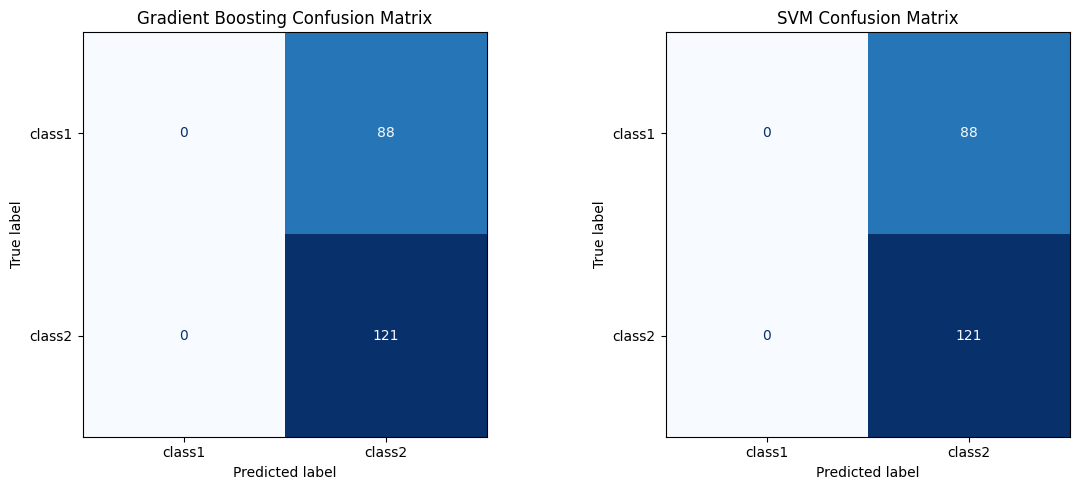

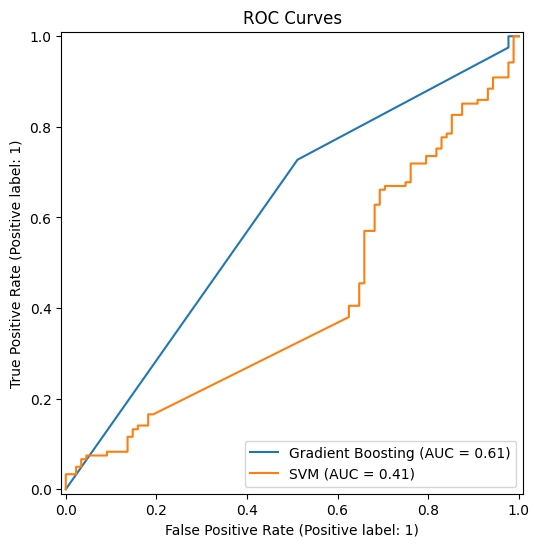

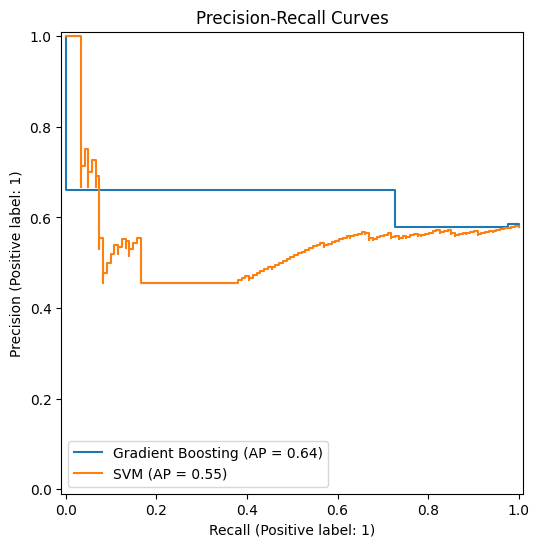

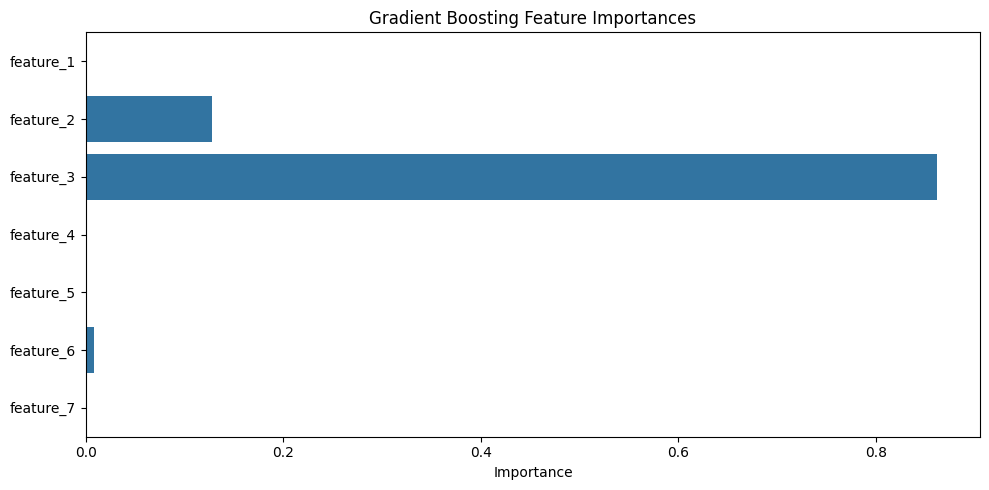

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
)

# Use the same test set from your notebook
y_pred_gb = best_gb.predict(X_test_scaled)
y_score_gb = best_gb.predict_proba(X_test_scaled)[:, 1]

y_pred_svc = best_svc.predict(X_test_scaled)
y_score_svc = best_svc.decision_function(X_test_scaled)

# Classification reports
print("Gradient Boosting classification report:")
print(classification_report(y_test, y_pred_gb, digits=4))
print("SVM classification report:")
print(classification_report(y_test, y_pred_svc, digits=4))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in zip(
    axes,
    [y_pred_gb, y_pred_svc],
    ["Gradient Boosting", "SVM"],
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["class1", "class2"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{title} Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test, y_score_gb, name="Gradient Boosting", ax=ax
)
RocCurveDisplay.from_predictions(
    y_test, y_score_svc, name="SVM", ax=ax
)
ax.set_title("ROC Curves")
plt.show()

# Precision-Recall curves
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(
    y_test, y_score_gb, name="Gradient Boosting", ax=ax
)
PrecisionRecallDisplay.from_predictions(
    y_test, y_score_svc, name="SVM", ax=ax
)
ax.set_title("Precision-Recall Curves")
plt.show()

# Feature importances for Gradient Boosting
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x=best_gb.feature_importances_,
    y=[f"feature_{i+1}" for i in range(best_gb.feature_importances_.shape[0])],
    ax=ax,
)
ax.set_title("Gradient Boosting Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

---
## 3. Reflection and Discussion

### Part 2 — Gradient Boosting and SVM

#### Model Performance
Gradient Boosting and SVM were tuned using GridSearchCV with 10-fold stratified cross-validation.

#### Gradient Boosting Analysis
- Builds trees **sequentially**, each correcting the previous one's errors
- `max_depth=1` (decision stumps) often performs well — reduces overfitting
- Lower `learning_rate` with more `n_estimators` generally gives better generalisation

#### SVM Analysis
- The **RBF kernel** maps features into a higher-dimensional space to separate non-linear classes
- `C` controls the trade-off between a wider margin and fewer misclassifications
- `gamma` controls how tightly the model fits the training data — high values risk overfitting
- Sensitive to feature scale — **normalisation was essential** before fitting SVM

#### Model Comparison

| Model | Strength | Weakness |
|---|---|---|
| Gradient Boosting | Handles feature interactions, robust | Slower to train, more hyperparameters |
| SVM (RBF) | Effective in high-dimensional spaces | Sensitive to scale, slow on large datasets |
| Logistic Regression | Fast, interpretable | Linear boundary only |
| Naïve Bayes | Very fast, low data needs | Assumes feature independence |

#### Conclusion
Both Gradient Boosting and SVM are capable models for this rice classification task.  
The best model depends on the trade-off between accuracy, training time, and interpretability.


---
## AI Acknowledgement


This notebook used AI assistance to implement Gradient Boosting and SVM, including cross-validation, hyperparameter tuning, and test-set evaluation